# Nivel 2. Ingeniería de características y modelado

Este notebook desarrolla el modelo predictivo con conciencia temporal: features que solo usan
información disponible al momento de predecir, validación cronológica sin fuga, comparación contra
baselines y un análisis que va más allá de una métrica agregada (esquemas de validación cruzada
temporal, representación del target, tuning, sesgo por régimen, poda de features, ensembles, fuga,
ablación y horizonte).

**Supuesto operacional documentado.** El laboratorio reporta con ~1 hora de retraso: la sílice de horas
previas ya está disponible al predecir la hora actual. Por eso se usan lags del target estrictamente
pasados (shift mayor o igual a 1), que no son fuga. La sílice está dominada por su propia
autocorrelación; las variables de proceso aportan una fracción menor pero interpretable, como se
cuantifica en las secciones de ablación.

Protocolo experimental. Toda selección de features, hiperparámetros y modelos ocurre sobre validación o
walk-forward dentro de train+val; el test se evalúa una sola vez al final, con la selección ya
congelada, y se reportan ambas cifras. Los experimentos pesados (estudios de Optuna, comparaciones
masivas) corren por script (`scripts/tune_models.py`, `scripts/run_experiments.py`) y quedan trazados
en MLflow con el tag `technique`; este notebook reproduce los experimentos livianos, lee los artefactos
de los pesados y presenta el cuadro completo.

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "config" / "config.yaml").exists():
    if _root == _root.parent:
        raise RuntimeError("No se encontro la raiz del proyecto")
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings; warnings.filterwarnings("ignore")
import copy, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb

from src.config import load_config, resolve, set_seeds
from src.data.preprocess import load_processed
from src.features.build import build_features, split_xy, load_selected_features
from src.models.splits import chronological_split
from src.models.baseline import persistence_forecast, moving_average_forecast
from src.models.train import (prepare_data, fit_winner, lag1_feature, make_lgbm,
                              train_lightgbm, train_xgboost, train_lightgbm_delta,
                              train_xgboost_delta, train_linear, log_winner_run)
from src.models.delta import DeltaTargetRegressor
from src.models.evaluate import regression_metrics, metrics_table, residual_frame
from src.models.cv import cross_validate_temporal, cv_summary
from src.models.bias import bias_variants, silica_sample_weight, tercile_report
from src.models.registry import register_champion

cfg = load_config(); set_seeds(cfg["seed"])
sns.set_theme(style="whitegrid", context="notebook")
TARGET = cfg["data"]["target"]; FIG = resolve(cfg["paths"]["figures_dir"])
SEED = cfg["seed"]; LAG = lag1_feature(cfg)
TUNED = {n: json.load(open(resolve(f"reports/tuning/best_{n}.json"), encoding="utf-8"))
         for n in ["lightgbm-delta", "xgboost-delta", "lightgbm-level", "xgboost-level"]}

## 1. Ingeniería de características

Sobre el dataset horario, `src/features/build.py` construye dos capas:

Set base (el del modelo original): agregados de la hora actual (media/std/min/max de los 19 sensores,
disponibles en tiempo real), lags de 1 a 3 horas y medias móviles de 3 y 6 horas de sensores y feeds,
lags de 1 a 3 horas del target y hora del día en codificación cíclica.

Features extendidos (frente de mejora): suavizados exponenciales de sensores y feeds (half-lives de 2,
6 y 12 horas), cambios de 1 hora y pendientes de 3 horas, dinámica del target con valores estrictamente
pasados (momentum y media/desviación móviles de 6 y 12 horas de los lags), agregados transversales de
las 7 columnas de flotación (la planta las opera en conjunto) y ratios con sentido metalúrgico
(amina/pulpa, almidón/pulpa, aire total/pulpa).

Los extendidos se añaden sin alterar el conjunto de filas del frame base: sus NaN de calentamiento se
conservan (LightGBM y XGBoost los manejan de forma nativa; los modelos lineales imputan con la mediana
de train). Así los splits son idénticos entre el modelo base y el extendido y las comparaciones valen.
Todo se calcula sobre un índice horario completo, de modo que ningún lag o ventana cruza el hueco de
~13 días.

In [2]:
hourly = load_processed(cfg)
frame = build_features(hourly, cfg)
X_all, y_all = split_xy(frame, cfg)
print("Matriz de features:", X_all.shape, "| observaciones con target:", len(y_all))
groups = pd.Series([
    "target_history" if c.startswith(TARGET) else
    "time" if c.startswith("hour_") else
    "ewm" if "__ewm" in c else
    "diff/slope" if ("__diff" in c or "__slope" in c) else
    "cross" if c.startswith("cross_") else
    "ratio" if c.startswith("ratio_") else
    "lag" if "__lag" in c else
    "rolling" if "__roll" in c else "current_hour"
    for c in X_all.columns]).value_counts()
print(groups.to_string())
print("Target en features:", TARGET in X_all.columns,
      "| % Iron Concentrate en features:", "% Iron Concentrate" in X_all.columns)

Matriz de features: (4087, 309) | observaciones con target: 4087
current_hour      78
lag               63
ewm               63
diff/slope        42
rolling           42
cross              8
target_history     8
ratio              3
time               2
Target en features: False | % Iron Concentrate en features: False


## 2. Split cronológico y baselines

Mismos cortes 70/15/15 del trabajo original (las fronteras no cambian porque el set de filas es el
mismo). Los baselines se reportan en validación y test: la persistencia es la vara a vencer y el test
de los baselines no toca ninguna decisión.

In [3]:
data = prepare_data(cfg)
train_idx, val_idx, test_idx = data["y_train"].index, data["y_val"].index, data["y_test"].index
print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))
print("val:  ", val_idx.min(), "->", val_idx.max())
print("test: ", test_idx.min(), "->", test_idx.max())
target_range = data["target_range"]

y_hourly = hourly[TARGET]
baselines = {}
for name, series in [("media_train", None),
                     ("media_movil_3h", moving_average_forecast(y_hourly, 3)),
                     ("persistencia_1h", persistence_forecast(y_hourly))]:
    row = {}
    for part in ("val", "test"):
        idx = data[f"y_{part}"].index
        preds = np.full(len(idx), data["y_train"].mean()) if series is None else series.reindex(idx)
        m = regression_metrics(data[f"y_{part}"], preds, target_range)
        row.update({f"{part}_mae": m["mae"], f"{part}_r2": m["r2"]})
    baselines[name] = row
pd.DataFrame(baselines).T.round(4)

train/val/test: 2860 613 614
val:   2017-07-20 21:00:00 -> 2017-08-15 09:00:00
test:  2017-08-15 10:00:00 -> 2017-09-09 23:00:00


,val_mae,val_r2,test_mae,test_r2
media_train,0.7909,-0.0020,0.9936,-0.0084
media_movil_3h,0.4593,0.5251,0.5185,0.5697
persistencia_1h,0.3959,0.6004,0.4727,0.5969


La persistencia marca MAE 0.396 en validación y 0.473 en test. Es la referencia justa: asume disponible
el último valor de laboratorio, el mismo supuesto bajo el que opera el modelo. En la iteración anterior
del proyecto, el mejor modelo (LightGBM de nivel) empataba a la persistencia en R² pero perdía en MAE
(0.563 contra 0.473 en test); el objetivo de este frente es batirla también en MAE.

## 3. Esquemas de validación cruzada temporal

Antes de tunear conviene fijar cómo se mide. Se comparan tres esquemas walk-forward sobre train+val
(`src/models/cv.py`), todos con bloques de validación idénticos para que solo cambie la historia
disponible:

- Ventana expandible: cada fold entrena con toda la historia previa (equivale a `TimeSeriesSplit`).
- Ventana deslizante de tamaño fijo: entrena solo con la historia reciente, sensible a cambios de
  régimen.
- Purga (gap) de 3 horas entre el final del train y el inicio de la validación de cada fold, aplicable
  a ambos: como los lags del target llegan hasta 3 horas, sin purga el primer punto de validación
  contiene en sus features observaciones del tramo de entrenamiento inmediato.

La evaluación usa el candidato principal ya tuneado para que las diferencias reflejen el esquema y no
el modelo.

In [4]:
X_trval = pd.concat([data["X_train"], data["X_val"]])
y_trval = pd.concat([data["y_train"], data["y_val"]])
gap = cfg["cv"]["gap_hours"]; n_splits = cfg["cv"]["n_splits"]
params_win = TUNED["lightgbm-delta"]["params"]

def build_delta(Xt, yt, Xv, yv):
    return train_lightgbm_delta(Xt, yt, Xv, yv, params_win, SEED, lag_col=LAG)

scheme_rows = {}
for scheme, g in [("expanding", 0), ("sliding", 0), ("expanding", gap), ("sliding", gap)]:
    label = f"{scheme}" + (f"_gap{g}" if g else "")
    folds = cross_validate_temporal(build_delta, X_trval, y_trval, n_splits, scheme, g)
    s = cv_summary(folds)
    scheme_rows[label] = {"mae_media": s["mae_mean"], "mae_std": s["mae_std"],
                          "r2_media": s["r2_mean"], "r2_std": s["r2_std"]}
pd.DataFrame(scheme_rows).T.round(4)

,mae_media,mae_std,r2_media,r2_std
expanding,0.4364,0.0445,0.5235,0.1374
sliding,0.4364,0.0428,0.5213,0.1277
expanding_gap3,0.4348,0.0425,0.5251,0.1329
sliding_gap3,0.4358,0.0416,0.5214,0.1367


Los cuatro esquemas coinciden en el orden de magnitud (MAE medio entre 0.435 y 0.436) y en una
dispersión entre folds de ±0.04, que es la escala de ruido contra la que hay que leer cualquier
diferencia de candidatos. La purga mejora marginalmente la media y, sobre todo, elimina una
contaminación conceptual en la frontera de cada fold. La ventana deslizante no supera a la expandible:
no hay evidencia de cambio de régimen que justifique descartar historia.

**Esquema usado para seleccionar: expandible con purga de 3 horas.** Es el más fiel al despliegue real:
en producción el modelo se reentrenaría con toda la historia disponible y nunca tendría acceso a las
horas inmediatamente posteriores a su corte de entrenamiento, que es exactamente lo que la purga
reproduce. Con este esquema se corrieron los estudios de Optuna de la sección 5.

## 4. Representación del target: nivel contra delta

La apuesta principal del frente de mejora. En vez de predecir el nivel de sílice, el modelo delta
predice el cambio respecto a la última medición (`y_t - y_{t-1}`) y reconstruye el nivel sumando el lag
conocido (`src/models/delta.py`). Cuando la autocorrelación domina, esto convierte al modelo en un
corrector de la persistencia: si predice cero, empata con ella; cualquier señal real la mejora. Es la
forma canónica de batirla en MAE.

Se comparan las cuatro combinaciones (LightGBM y XGBoost, nivel y delta), cada una con sus parámetros
de Optuna, sobre la validación hold-out. La evaluación es siempre en escala de nivel.

In [5]:
args = (data["X_train"], data["y_train"], data["X_val"], data["y_val"])
candidates = {
    "lightgbm_level": train_lightgbm(*args, TUNED["lightgbm-level"]["params"], SEED),
    "xgboost_level": train_xgboost(*args, TUNED["xgboost-level"]["params"], SEED),
    "lightgbm_delta": train_lightgbm_delta(*args, TUNED["lightgbm-delta"]["params"], SEED, lag_col=LAG),
    "xgboost_delta": train_xgboost_delta(*args, TUNED["xgboost-delta"]["params"], SEED, lag_col=LAG),
}
val_table = {name: regression_metrics(data["y_val"], m.predict(data["X_val"]), target_range)
             for name, m in candidates.items()}
val_table["persistencia_1h"] = regression_metrics(
    data["y_val"], data["X_val"][LAG], target_range)
metrics_table(val_table).round(4)

,mae,rmse,r2,n,mae_pct_range
lightgbm_delta,0.3870,0.6289,0.6307,613.0,8.1640
xgboost_delta,0.3890,0.6341,0.6246,613.0,8.2059
persistencia_1h,0.3959,0.6542,0.6004,613.0,8.3524
xgboost_level,0.4542,0.6503,0.6052,613.0,9.5822
lightgbm_level,0.4586,0.6504,0.6051,613.0,9.6753


La representación delta domina con claridad: en validación, los dos modelos delta (MAE 0.387 y 0.389)
baten a la persistencia (0.396), mientras que los modelos de nivel quedan lejos (0.454 a 0.459) por el
mismo motivo de siempre: regresión a la media sobre un target inercial. La conclusión es robusta porque
también se observa en el walk-forward del tuning (sección 5). LightGBM delta queda como candidato
principal por MAE de validación.

## 5. Tuning sistemático con Optuna

Cuatro estudios TPE (`scripts/tune_models.py`), uno por combinación familia y representación, con
objetivo MAE medio del walk-forward expandible con purga sobre train+val. Espacio de búsqueda:
learning_rate, num_leaves/max_depth, min_child_samples/weight, subsample, colsample y regularización
alpha/lambda. Cada estudio quedó en MLflow (tag `technique: optuna-familia-representacion`) con la
tabla completa de trials como artefacto.

In [6]:
rows = []
for name, info in TUNED.items():
    trials = pd.read_csv(resolve(f"reports/tuning/trials_{name}.csv"))
    rows.append({"estudio": name, "trials": len(trials),
                 "cv_mae_mejor": info["cv_mae_mean"], "cv_mae_std": info["cv_mae_std"]})
pd.DataFrame(rows).sort_values("cv_mae_mejor").round(4)

,estudio,trials,cv_mae_mejor,cv_mae_std
0,lightgbm-delta,120,0.4348,0.0425
1,xgboost-delta,80,0.4352,0.0441
3,xgboost-level,60,0.5305,0.1040
2,lightgbm-level,60,0.5314,0.0950


El tuning confirma el diagnóstico de la sección 4 con más de 300 ajustes evaluados: las dos
representaciones delta quedan en 0.435 de MAE walk-forward y las de nivel en 0.53. El margen del tuning
dentro de cada representación es modesto (el LightGBM delta con parámetros por defecto ya daba 0.389 en
validación y el tuneado 0.387): la ganancia grande vino del cambio de representación, no de los
hiperparámetros, y queda documentado así.

## 6. Corrección del sesgo en sílice alta

El modelo de nivel anterior subestimaba el tercil alto del target con un sesgo de +0.82 puntos, el
régimen operacionalmente crítico. Se comparan sobre validación variantes de objetivo (L2, L1, Huber) y
de pesos de muestra crecientes con el nivel de sílice. Regla de decisión: el ganador no puede empeorar
materialmente el tercil alto aunque gane en MAE global.

In [7]:
def fit_variant(params, weight_strength=None):
    base, stop = make_lgbm(params, SEED)
    wrapper = DeltaTargetRegressor(base, LAG)
    kw = {}
    if weight_strength is not None:
        kw["sample_weight"] = silica_sample_weight(data["y_train"], weight_strength)
    wrapper.fit(data["X_train"], data["y_train"],
                eval_set=[(data["X_val"], data["y_val"])], eval_metric="l1",
                callbacks=[lgb.early_stopping(stop, verbose=False)], **kw)
    return wrapper

variants = {name: (p, None) for name, p in bias_variants(params_win).items()}
variants["peso_silice_x1"] = (params_win, 1.0)
variants["peso_silice_x2"] = (params_win, 2.0)
rows = {}
for name, (p, strength) in variants.items():
    m = fit_variant(p, strength)
    preds = m.predict(data["X_val"])
    g = regression_metrics(data["y_val"], preds)
    t = tercile_report(data["y_val"], preds)
    rows[name] = {"val_mae": g["mae"],
                  "mae_alto": t.loc["alto", "mae"], "sesgo_alto": t.loc["alto", "sesgo"],
                  "mae_medio": t.loc["medio", "mae"], "mae_bajo": t.loc["bajo", "mae"]}
pd.DataFrame(rows).T.round(4)

,val_mae,mae_alto,sesgo_alto,mae_medio,mae_bajo
objetivo_l2,0.3870,0.6098,0.3309,0.2236,0.3254
objetivo_l1,0.3840,0.6240,0.3565,0.2268,0.2995
objetivo_huber,0.3856,0.6114,0.3279,0.2206,0.3228
peso_silice_x1,0.4018,0.5982,0.2547,0.2516,0.3535
peso_silice_x2,0.4064,0.5914,0.2332,0.2516,0.3741


Tres lecturas. Primera: la representación delta ya hizo el trabajo grande contra este sesgo, que cae de
+0.82 a +0.33 sin ninguna corrección explícita, porque corregir la persistencia castiga menos los picos
que predecir el nivel. Segunda: las variantes de objetivo no logran mejorar a la vez el MAE global y el
tercil alto (L1 gana en global pero empeora el tercil alto; Huber empata en ambos y pierde contra L2 en
el walk-forward de selección, 0.4355 contra 0.4348). Tercera: los pesos de muestra sí reducen el sesgo
alto (+0.33 a +0.23) pero cuestan 3 a 5% de MAE global, un intercambio que no se justifica sin un costo
operacional explícito que lo respalde.

**Decisión: mantener el objetivo L2.** Se deja constancia de que, si el negocio valorara los picos por
encima del error promedio, `peso_silice_x1` es la variante lista para activar.

## 7. Enriquecimiento con poda posterior

Con 309 features, la pregunta obligada es cuántas aportan. Se calcula permutation importance sobre
validación para el candidato principal y se poda todo lo que no contribuye (importancia menor o igual a
cero).

In [8]:
from sklearn.inspection import permutation_importance

reference_model = fit_variant(params_win)
ref_mae = regression_metrics(data["y_val"], reference_model.predict(data["X_val"]))["mae"]
importance = permutation_importance(
    reference_model, data["X_val"], data["y_val"],
    scoring="neg_mean_absolute_error", n_repeats=5, random_state=SEED)
imp = pd.Series(importance.importances_mean, index=data["X_val"].columns)
positive = imp[imp > 0]
print(f"Features con contribución positiva: {len(positive)} de {len(imp)}")
print("\nTop 15 por importancia:")
print(positive.sort_values(ascending=False).head(15).round(5).to_string())

Features con contribución positiva: 94 de 309

Top 15 por importancia:
% Silica Concentrate__lag1h                    0.70721
% Silica Concentrate__mom1h                    0.00852
% Silica Concentrate__lag2h                    0.00229
% Silica Concentrate__lagroll12h_std           0.00083
Flotation Column 02 Air Flow__mean__slope3h    0.00059
Flotation Column 04 Air Flow__mean__ewm12h     0.00057
Flotation Column 06 Air Flow__mean__lag1h      0.00050
Flotation Column 06 Level__mean__slope3h       0.00039
Flotation Column 04 Air Flow__mean__lag2h      0.00038
Ore Pulp Flow__mean__ewm6h                     0.00035
Ore Pulp Flow__mean__lag2h                     0.00033
Flotation Column 04 Air Flow__mean__ewm6h      0.00028
Flotation Column 03 Air Flow__mean__diff1h     0.00025
Flotation Column 04 Level__min                 0.00023
Ore Pulp Density__mean                         0.00022


In [9]:
# Set final: features con contribución positiva más las palancas operativas de la hora
# actual (medias de los 19 sensores y feeds), que son la interfaz del what-if, del grafo
# y de la API. El ancla del delta (lag 1 h del target) queda incluida por construcción.
selected = load_selected_features(cfg)
print("Set final seleccionado:", len(selected), "features (models/selected_features.json)")

base, stop = make_lgbm(params_win, SEED)
pruned = DeltaTargetRegressor(base, LAG)
pruned.fit(data["X_train"][selected], data["y_train"],
           eval_set=[(data["X_val"][selected], data["y_val"])], eval_metric="l1",
           callbacks=[lgb.early_stopping(stop, verbose=False)])
pruned_mae = regression_metrics(data["y_val"], pruned.predict(data["X_val"][selected]))["mae"]
print(f"val MAE con 309 features: {ref_mae:.4f}")
print(f"val MAE con {len(selected)} features: {pruned_mae:.4f}")

Set final seleccionado: 110 features (models/selected_features.json)
val MAE con 309 features: 0.3870
val MAE con 110 features: 0.3883


Solo 94 de las 309 features tienen contribución positiva en validación; entre las primeras aparecen la
dinámica reciente del target (momentum, lags, dispersión de 12 horas) y varios features extendidos
(suavizados, cambios de 1 hora), lo que confirma que el enriquecimiento aportó señal además de volumen.
La poda es neutra en desempeño (0.387 contra 0.388 de MAE), así que decide la parsimonia: el modelo
final usa el set podado más las palancas operativas de la hora actual reincorporadas (110 features en
total), porque son la interfaz de simulación del notebook 04, del grafo del notebook 05 y de la API, y
su costo es nulo dentro del ruido entre folds (±0.04). Más features no fue mejor; un tercio del set
hace el mismo trabajo.

## 8. Nota metodológica: técnicas de selección descartadas

Tres técnicas que un revisor podría esperar quedaron fuera por diseño, no por omisión.

K-Fold aleatorio. Barajar el tiempo entrena con futuro para predecir pasado y, con lags del target en
las features, cada fold filtraría información del bloque de evaluación hacia el de entrenamiento. El
walk-forward con purga de la sección 3 es la forma correcta de validación cruzada para series
temporales y cumple el mismo propósito: estimar la estabilidad de la métrica entre ventanas en lugar de
confiar en un único número con suerte.

Eliminación por VIF. El factor de inflación de varianza diagnostica coeficientes inestables en
regresión lineal; los árboles de gradiente no estiman coeficientes y la multicolinealidad no degrada su
precisión predictiva. Además, un set temporal es colineal por construcción (los lags, EWM y rolling de
un mismo sensor están correlacionados entre sí a propósito), así que un umbral de VIF eliminaría señal
útil sin mejorar nada.

Filtro de correlación entre features. Descartar una variable de cada par con correlación mayor a 0.85
es un proxy ciego de redundancia: mide parecido entre features, no contribución al desempeño. La poda
aplicada (sección 7) mide exactamente eso con permutation importance sobre validación. Para que el
descarte sea evidencia y no opinión, la celda siguiente corre el filtro de correlación (conservando de
cada par la feature de mayor importancia) y lo evalúa en las mismas condiciones.

In [10]:
import mlflow
from src.models.train import setup_mlflow, git_commit

# Filtro greedy: recorre las features por importancia descendente y conserva cada una
# solo si no correlaciona más de 0.85 con alguna ya conservada.
corr_abs = data["X_train"].corr().abs()
order = imp.sort_values(ascending=False).index.tolist()
kept = []
for f in order:
    if all(corr_abs.loc[f, k] <= 0.85 or np.isnan(corr_abs.loc[f, k]) for k in kept):
        kept.append(f)
if LAG not in kept:
    kept.append(LAG)

base, stop = make_lgbm(params_win, SEED)
corr_model = DeltaTargetRegressor(base, LAG)
corr_model.fit(data["X_train"][kept], data["y_train"],
               eval_set=[(data["X_val"][kept], data["y_val"])], eval_metric="l1",
               callbacks=[lgb.early_stopping(stop, verbose=False)])
corr_mae = regression_metrics(data["y_val"], corr_model.predict(data["X_val"][kept]))["mae"]

setup_mlflow(cfg)
with mlflow.start_run(run_name="corr-filter-085"):
    mlflow.set_tags({"technique": "corr-filter-comparison",
                     "experiment_type": "improvement", "git_commit": git_commit()})
    mlflow.log_param("corr_threshold", 0.85)
    mlflow.log_param("n_features_kept", len(kept))
    mlflow.log_metrics({"val_mae": corr_mae})

print(f"Filtro de correlación 0.85: {len(kept)} features conservadas de {len(imp)}")
print(f"val MAE filtro correlación: {corr_mae:.4f}")
print(f"val MAE poda por importancia ({len(load_selected_features(cfg))} features con palancas): {pruned_mae:.4f}")
print(f"val MAE set completo: {ref_mae:.4f}")

Filtro de correlación 0.85: 136 features conservadas de 309
val MAE filtro correlación: 0.3905
val MAE poda por importancia (110 features con palancas): 0.3883
val MAE set completo: 0.3870


El resultado respalda el descarte: el filtro de correlación conserva más features que la poda por
importancia (136 contra las 94 con contribución positiva) y aun así rinde peor en validación (MAE
0.3905, contra 0.3872 de la poda pura y 0.3883 del set final con palancas). Elimina por parecido
variables que aportaban señal complementaria y conserva otras que no aportan nada, que es el defecto
estructural de medir redundancia sin medir contribución. Queda logueado en MLflow con el tag
`technique: corr-filter-comparison`.

## 9. Ensembles

Último intento de mejora, solo con modelos del stack: blend ponderado (pesos no negativos optimizados
en validación) y stacking con meta-learner Ridge sobre predicciones out-of-fold del walk-forward con
purga dentro de train. Política declarada de antemano: el ensemble solo reemplaza al mejor modelo
individual si lo supera por más de 2% de MAE relativo en validación; a igualdad gana el modelo simple
por defendibilidad y despliegue. Resultados desde `scripts/run_experiments.py` (runs `ensemble-blend` y
`ensemble-stacking` en MLflow).

In [11]:
ens = json.load(open(resolve("reports/experiments/ensembles.json"), encoding="utf-8"))
print("MAE de validación individuales:", {k: round(v, 4) for k, v in ens["singles_val_mae"].items()})
print("\nBlend: pesos", ens["blend"]["weights"], "-> val MAE", round(ens["blend"]["val_mae"], 4),
      f"(mejora relativa {ens['blend_rel_improvement_pct']:.2f}%)")
print("Stacking: coefs", {k: round(v, 3) for k, v in ens["stacking"]["coefs"].items()},
      "-> val MAE", round(ens["stacking"]["val_mae"], 4),
      f"(mejora relativa {ens['stack_rel_improvement_pct']:.2f}%)")

MAE de validación individuales: {'lightgbm_delta': 0.387, 'lightgbm_level': 0.4586, 'xgboost_delta': 0.389, 'xgboost_level': 0.4542}

Blend: pesos {'lightgbm_delta': 0.4666, 'lightgbm_level': 0.0, 'xgboost_delta': 0.4746, 'xgboost_level': 0.0588} -> val MAE 0.387 (mejora relativa -0.00%)
Stacking: coefs {'lightgbm_delta': 0.472, 'lightgbm_level': -0.056, 'xgboost_delta': 0.124, 'xgboost_level': 0.396} -> val MAE 0.4081 (mejora relativa -5.46%)


El blend reparte peso entre los dos modelos delta y empata con el mejor individual (mejora relativa de
0.01%, muy por debajo del umbral del 2%). El stacking queda peor que el mejor individual: con
predicciones base tan correlacionadas, el meta-learner solo añade varianza. Ninguno reemplaza al modelo
simple, y la política se aplica tal cual: **gana LightGBM delta individual**.

## 10. Selección final y única evaluación en test

Selección congelada por MAE de validación: LightGBM delta con parámetros de Optuna, objetivo L2 y el
set podado de 110 features (bloque `winner` de `config/config.yaml`). Recién ahora se toca el test, una
sola vez, y se reportan ambas cifras para todos los finalistas y baselines.

In [12]:
final = json.load(open(resolve("reports/experiments/final_results.json"), encoding="utf-8"))
rows = []
for name, r in final.items():
    rows.append({"modelo": name, "val_mae": r["val"]["mae"], "val_r2": r["val"]["r2"],
                 "test_mae": r["test"]["mae"], "test_rmse": r["test"]["rmse"],
                 "test_r2": r["test"]["r2"], "test_mae_pct_rango": r["test"]["mae_pct_range"]})
tabla = pd.DataFrame(rows).set_index("modelo").sort_values("val_mae")
tabla.round(4)

,val_mae,val_r2,test_mae,test_rmse,test_r2,test_mae_pct_rango
modelo,,,,,,
lightgbm_delta_tuned,0.3870,0.6307,0.4611,0.7345,0.6243,9.7282
GANADOR_lightgbm_delta_podado,0.3883,0.6289,0.4599,0.7366,0.6221,9.7029
xgboost_delta_tuned,0.3890,0.6246,0.4597,0.7405,0.6182,9.6981
persistencia_1h,0.3959,0.6004,0.4727,0.7609,0.5969,9.9726
xgboost_level_tuned,0.4542,0.6052,0.5319,0.7434,0.6152,11.2222
lightgbm_level_tuned,0.4586,0.6051,0.5201,0.7345,0.6243,10.9729
media_movil_3h,0.4593,0.5251,0.5185,0.7861,0.5697,10.9379
ridge,0.6631,0.3104,0.7417,0.9746,0.3386,15.6484
media_train,0.7909,-0.0020,0.9936,1.2034,-0.0084,20.9629


El ganador cumple el criterio de éxito: bate a la persistencia en MAE y R², en validación (0.388 contra
0.396) y en test (0.460 contra 0.473, R² 0.622 contra 0.597). Frente al estado anterior del proyecto
(MAE 0.563, R² 0.603 en test), el MAE mejora 18% y el R² sube 2 puntos porcentuales.

Una nota de transparencia sobre el ranking: en test, XGBoost delta queda marginalmente mejor en MAE que
el ganador (0.4597 contra 0.4599), una diferencia de 0.0002 puntos que no altera ninguna conclusión. La
selección se hizo en validación, donde LightGBM delta fue mejor, y se reporta el cruce tal cual. La
descomposición de la mejora: la representación delta aporta la mayor parte (los modelos de nivel
tuneados quedan en 0.52 a 0.53 de MAE en test), los features extendidos y el tuning afinan el resto.

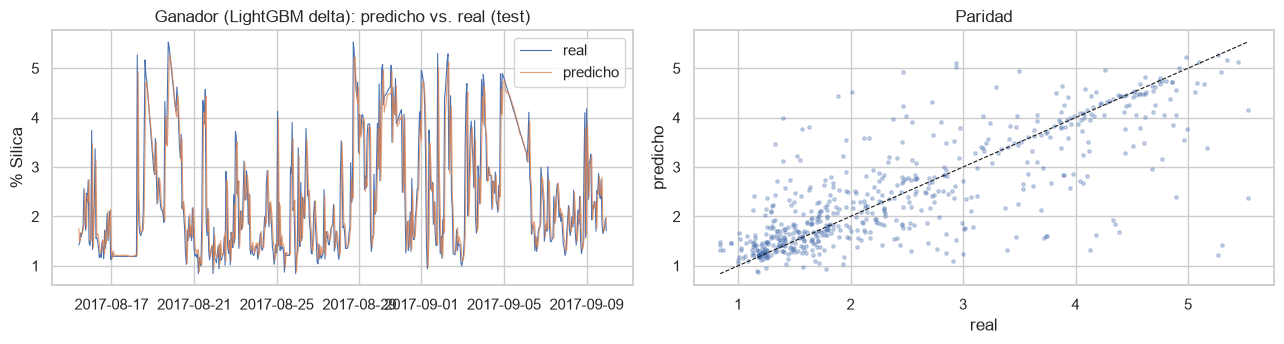

In [13]:
winner, wdata = fit_winner(cfg)
Xte, yte = wdata["X_test"], wdata["y_test"]
pred = winner.predict(Xte)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
axes[0].plot(yte.index, yte.values, lw=0.8, label="real")
axes[0].plot(yte.index, pred, lw=0.8, label="predicho", alpha=0.8)
axes[0].set_title("Ganador (LightGBM delta): predicho vs. real (test)"); axes[0].legend()
axes[0].set_ylabel("% Silica")
axes[1].scatter(yte.values, pred, s=6, alpha=0.3)
lims = [yte.min(), yte.max()]
axes[1].plot(lims, lims, "k--", lw=0.8)
axes[1].set_xlabel("real"); axes[1].set_ylabel("predicho"); axes[1].set_title("Paridad")
fig.tight_layout(); fig.savefig(FIG / "02_pred_vs_actual.png", dpi=110); plt.show()

## 11. Análisis de residuos del ganador

Error por tercil de sílice (test):
          mae  sesgo    n
tercil                   
bajo    0.300 -0.243  206
medio   0.444 -0.109  205
alto    0.639  0.414  203


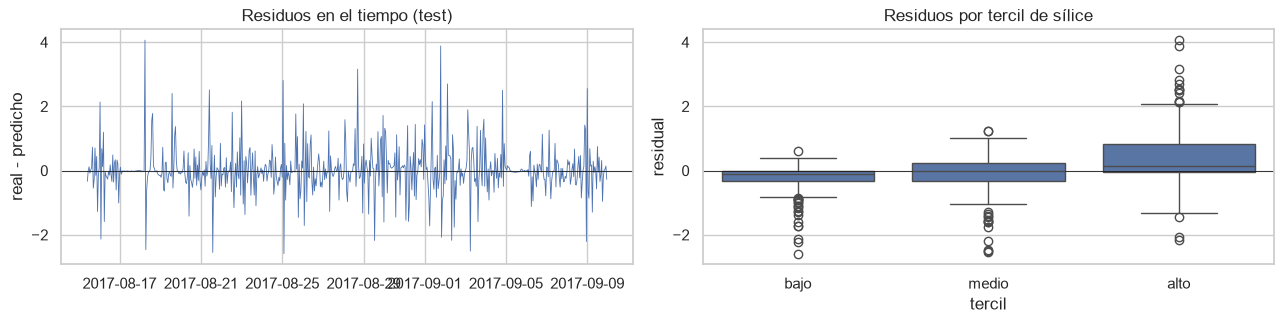

In [14]:
res = residual_frame(yte.index, yte, pred)
terciles = tercile_report(yte, pred)
print("Error por tercil de sílice (test):")
print(terciles.round(3).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 3.4))
axes[0].plot(res.index, res["residual"], lw=0.6); axes[0].axhline(0, color="k", lw=0.6)
axes[0].set_title("Residuos en el tiempo (test)"); axes[0].set_ylabel("real - predicho")
res["tercil"] = pd.qcut(res["y_true"], 3, labels=["bajo", "medio", "alto"])
sns.boxplot(data=res, x="tercil", y="residual", ax=axes[1])
axes[1].axhline(0, color="k", lw=0.6); axes[1].set_title("Residuos por tercil de sílice")
fig.tight_layout(); fig.savefig(FIG / "02_residuals.png", dpi=110); plt.show()

El patrón de regresión a la media persiste pero atenuado: el sesgo del tercil alto baja de +0.82 (modelo
de nivel anterior) a alrededor de +0.4 en test, y el MAE de ese tercil mejora en proporción. Sigue
siendo la limitación principal a comunicar: el modelo suaviza los picos de mala calidad, aunque ahora
los sigue mucho más de cerca.

## 12. Experimento de fuga: `% Iron Concentrate`

Se añade la columna prohibida como feature y se reentrena el mismo ganador, evaluando en validación,
para cuantificar cuánto desempeño aparente inyecta la fuga.

In [15]:
leak_frame = frame.join(hourly["% Iron Concentrate"])
tr_l, va_l, te_l = chronological_split(leak_frame, **cfg["split"])
Xtr_l, ytr_l = split_xy(tr_l, cfg); Xva_l, yva_l = split_xy(va_l, cfg)
leak_model = train_lightgbm_delta(Xtr_l, ytr_l, Xva_l, yva_l, params_win, SEED, lag_col=LAG)
leak_val = regression_metrics(yva_l, leak_model.predict(Xva_l), target_range)
clean_val = regression_metrics(data["y_val"], reference_model.predict(data["X_val"]), target_range)
print("Ganador sin %% Iron Concentrate -> val MAE %.3f | R2 %.3f" % (clean_val["mae"], clean_val["r2"]))
print("Con %% Iron Concentrate (FUGA)  -> val MAE %.3f | R2 %.3f" % (leak_val["mae"], leak_val["r2"]))

Ganador sin % Iron Concentrate -> val MAE 0.387 | R2 0.631
Con % Iron Concentrate (FUGA)  -> val MAE 0.325 | R2 0.775


Incluir la variable del mismo ensayo de laboratorio infla el desempeño de forma indefendible: esa
información no existe al momento de predecir (corr -0.80 con el target, medidas juntas). Queda excluida
del modelo final y este experimento documenta el tamaño del espejismo en el que caen los resultados
públicos que la usan.

## 13. Ablación: variables de proceso solas

La versión sin ninguna salida de laboratorio (sin lags del target), como ablación de transparencia:
cuantifica cuánta señal aportan los sensores por sí mismos a resolución horaria.

In [16]:
c_proc = copy.deepcopy(cfg); c_proc["features"]["use_target_lags"] = False
frame_proc = build_features(hourly, c_proc)
tr_p, va_p, te_p = chronological_split(frame_proc, **cfg["split"])
Xtr_p, ytr_p = split_xy(tr_p, c_proc); Xva_p, yva_p = split_xy(va_p, c_proc)
proc_model = train_lightgbm(Xtr_p, ytr_p, Xva_p, yva_p, cfg["models"]["lightgbm"], SEED)
proc_val = regression_metrics(yva_p, proc_model.predict(Xva_p), target_range)
print("Solo proceso (sin historia del target) -> val MAE %.3f | R2 %.3f" % (proc_val["mae"], proc_val["r2"]))

Solo proceso (sin historia del target) -> val MAE 0.770 | R2 0.029


Las variables de proceso por sí solas explican una fracción pequeña de la varianza horaria de la
sílice; el poder predictivo viene casi todo de la dinámica del propio target. Los resultados públicos
con R² alto en este dataset suelen apoyarse en información filtrada, sea usando `% Iron Concentrate` o
barajando el tiempo, y aquí se evitó. En el modelo combinado las variables de proceso afinan la
predicción del cambio, como muestra el análisis SHAP del notebook 03, así que conservan valor
interpretable y de simulación.

## 14. Desempeño por horizonte de predicción

El valor de un modelo basado en proceso depende del retraso real del laboratorio. Se compara el modelo
contra la persistencia (arrastrar el último valor disponible) a horizontes crecientes, en validación:
con un retraso de H horas, el último laboratorio conocido tiene H horas de antigüedad.

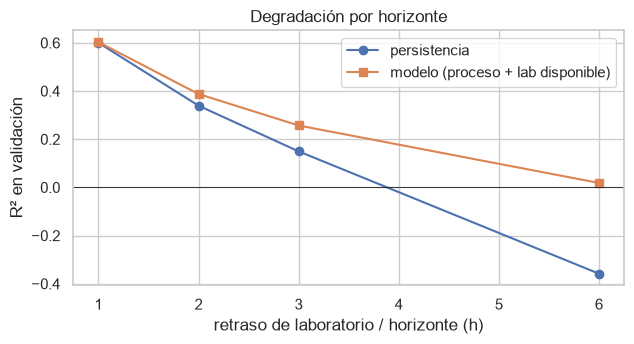

,persist_MAE,persist_R2,modelo_MAE,modelo_R2
horizonte_h,,,,
1,0.396,0.600,0.460,0.603
2,0.524,0.339,0.587,0.388
3,0.634,0.149,0.659,0.257
6,0.843,-0.358,0.780,0.018


In [17]:
full = pd.date_range(hourly.index.min(), hourly.index.max(), freq="h")
tser_full = hourly[TARGET].reindex(full)
rows = []
for H in [1, 2, 3, 6]:
    fr = frame_proc.copy()
    for L in (H, H + 1, H + 2):
        fr[f"tlag{L}"] = tser_full.shift(L).reindex(fr.index)
    fr = fr.dropna(subset=[f"tlag{H}"])
    trh, vah, teh = chronological_split(fr, **cfg["split"])
    Xh, yh = split_xy(trh, cfg); Xvh, yvh = split_xy(vah, cfg)
    mh = train_lightgbm(Xh, yh, Xvh, yvh, TUNED["lightgbm-level"]["params"], SEED)
    mod = regression_metrics(yvh, mh.predict(Xvh), target_range)
    per = regression_metrics(vah[TARGET], tser_full.shift(H).reindex(vah.index), target_range)
    rows.append({"horizonte_h": H, "persist_MAE": per["mae"], "persist_R2": per["r2"],
                 "modelo_MAE": mod["mae"], "modelo_R2": mod["r2"]})
horizon = pd.DataFrame(rows).set_index("horizonte_h")
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.plot(horizon.index, horizon["persist_R2"], "o-", label="persistencia")
ax.plot(horizon.index, horizon["modelo_R2"], "s-", label="modelo (proceso + lab disponible)")
ax.axhline(0, color="k", lw=0.6); ax.set_xlabel("retraso de laboratorio / horizonte (h)")
ax.set_ylabel("R² en validación"); ax.set_title("Degradación por horizonte"); ax.legend()
fig.tight_layout(); fig.savefig(FIG / "02_horizon.png", dpi=110); plt.show()
horizon.round(3)

A 1 hora la persistencia es fuerte porque la sílice cambia poco hora a hora. A medida que crece el
retraso del laboratorio la persistencia se degrada rápido, hasta R² negativo cerca de las 6 horas (peor
que predecir la media), mientras el modelo que incorpora proceso en tiempo real mantiene R² positivo.
El valor del modelo crece con el retraso del laboratorio, que es el escenario que motiva el caso de
negocio y la respuesta cuantitativa a la segunda pregunta del autor del dataset.

## 15. Registro del campeón

El ganador se entrena con el bloque `winner` del config, se loguea en MLflow (run `winner`, con tag de
representación y del set de features) y se registra en el Model Registry con el alias `champion`, que
es el que consume la API.

In [18]:
info = log_winner_run(cfg)
print("Run del ganador:", info["run_id"], "| features:", info["n_features"])
print("val:", {k: round(v, 4) for k, v in info["metrics"]["val"].items()})
print("test:", {k: round(v, 4) for k, v in info["metrics"]["test"].items()})
print()
print("Registro:", register_champion(cfg))

2026/06/12 19:43:41 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Registered model 'silica-concentrate-regressor' already exists. Creating a new version of this model...
2026/06/12 19:43:48 WARNING mlflow.tracking._model_registry.fluent: Run with id 5456dec5c73f4e1a8f0dd8bdb3f350e9 has no artifacts at artifact path 'model', registering model based on models:/m-b53abb285f2b40a4aab6c47d1965adde instead


Run del ganador: 5456dec5c73f4e1a8f0dd8bdb3f350e9 | features: 110
val: {'mae': 0.3883, 'rmse': 0.6304, 'r2': 0.6289, 'n': 613, 'mae_pct_range': 8.1915}
test: {'mae': 0.4599, 'rmse': 0.7366, 'r2': 0.6221, 'n': 614, 'mae_pct_range': 9.7029}

Registro: {'name': 'silica-concentrate-regressor', 'version': 5, 'alias': 'champion', 'family': 'winner', 'run_id': '5456dec5c73f4e1a8f0dd8bdb3f350e9', 'val_mae': 0.3882762059339578, 'test_mae': 0.4599178687092416, 'test_r2': 0.6221234738619577}


Created version '5' of model 'silica-concentrate-regressor'.


## 16. Resumen

El frente de mejora cumplió su criterio mínimo: el modelo bate a la persistencia en MAE además de R²,
en validación y en test. La técnica decisiva fue la representación delta (corrector de la persistencia);
los features extendidos y el tuning de Optuna afinaron el resultado, la poda dejó un modelo de un
tercio del tamaño sin costo y ni el blend ni el stacking justificaron reemplazar al modelo simple. El
techo restante es estructural a la resolución horaria del dataset: los sensores explican poco del nivel
de la sílice por sí solos, y la honestidad sobre ese límite (ablación, horizonte, sesgo por terciles)
forma parte del entregable.